# HW1: Phoneme Recognition with SSL

**Authors**: Roman Pavlosiuk, Iryna Denysova


## 1. Setup

In [1]:
#!wget https://narrow-san-conditional-terminology.trycloudflare.com/archive.zip
#!unzip archive.zip
#!pip install -q transformers soundfile editdistance tqdm seaborn

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import gc
import re
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import soundfile as sf
import IPython.display as ipd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from transformers import AutoFeatureExtractor, Wav2Vec2Model, HubertModel
from transformers import logging as hf_logging
from tqdm import tqdm

try:
    import editdistance as _ed
    def edit_distance(a, b): return _ed.eval(a, b)
except ImportError:
    def edit_distance(a, b):
        m, n = len(a), len(b)
        dp = list(range(n + 1))
        for i in range(1, m + 1):
            prev, dp[0] = dp[0], i
            for j in range(1, n + 1):
                prev, dp[j] = dp[j], prev if a[i-1]==b[j-1] else 1+min(prev, dp[j], dp[j-1])
        return dp[n]

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__}  |  device: {DEVICE}')

PyTorch 2.10.0+cu128  |  device: cuda


Here we define two constants we will use everywhere:
- `SAMPLE_RATE = 16000` - TIMIT audio is recorded at 16 kHz (16 000 samples per second)
- `CNN_STRIDE = 320` - the CNN inside the SSL model compresses every 320 audio samples into one feature vector

In [3]:
DATA_DIR  = './archive/data'
TRAIN_CSV = './archive/train_data.csv'
TEST_CSV  = './archive/test_data.csv'

SAMPLE_RATE = 16_000
CNN_STRIDE  = 320

In [4]:
CHECKPOINT_DIR = './checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def _ckpt_path(name):
    safe = re.sub(r'[^\w\-]', '_', name)
    return os.path.join(CHECKPOINT_DIR, safe + '.pt')

## 2. Phoneme Vocabulary

TIMIT uses **61 different phonemes** in its labels. The standard way to evaluate phoneme recognition maps them down to **39 phonemes** - some phonemes that sound almost the same get merged, and the glottal stop `q` is just deleted. We always measure PER on 39 phonemes, so we need this mapping from the start.

Here we create the fold map (61 -> 39) and the full 39-phoneme list. We also build two lookup dictionaries: phoneme name -> index and index -> phoneme name.

In [5]:
FOLD_MAP = {
    'ao':'aa', 'ax':'ah', 'ax-h':'ah', 'axr':'er',
    'hv':'hh', 'ix':'ih', 'el':'l',   'em':'m',
    'en':'n',  'nx':'n',  'eng':'ng',  'zh':'sh',
    'ux':'uw',
    'pcl':'sil', 'tcl':'sil', 'kcl':'sil',
    'bcl':'sil', 'dcl':'sil', 'gcl':'sil',
    'h#':'sil',  'pau':'sil', 'epi':'sil',
    'q': None,
}

PHONEMES_39 = [
    'aa','ae','ah','aw','ay','b','ch','d','dh','dx',
    'eh','er','ey','f','g','hh','ih','iy','jh','k',
    'l','m','n','ng','ow','oy','p','r','s','sh',
    'sil','t','th','uh','uw','v','w','y','z',
]
PHONE2IDX = {p: i for i, p in enumerate(PHONEMES_39)}
IDX2PHONE = {i: p for i, p in enumerate(PHONEMES_39)}
NUM_PHONEMES = len(PHONEMES_39)

def normalize_phone(phone: str):
    phone = phone.lower()
    return FOLD_MAP.get(phone, phone)

print(f'Phoneme set size: {NUM_PHONEMES}')
print('Phonemes:', PHONEMES_39)

Phoneme set size: 39
Phonemes: ['aa', 'ae', 'ah', 'aw', 'ay', 'b', 'ch', 'd', 'dh', 'dx', 'eh', 'er', 'ey', 'f', 'g', 'hh', 'ih', 'iy', 'jh', 'k', 'l', 'm', 'n', 'ng', 'ow', 'oy', 'p', 'r', 's', 'sh', 'sil', 't', 'th', 'uh', 'uw', 'v', 'w', 'y', 'z']


## 3. Data Loading

Now we load the data. Each utterance (one audio recording by one speaker) comes with two files: a `.wav` audio file and a `.PHN` label file that lists exactly which phoneme was spoken at each moment. We write helper functions to read these files and prepare them for training.

These are our helper functions:
- `read_phn_file` reads a `.PHN` file (format: `start_sample  end_sample  phoneme`) and applies the 61 -> 39 fold map
- `segments_to_frame_labels` maps PHN timing (in samples) to SSL frame indices - for each output frame we look at its centre sample and find which phoneme it falls in
- `load_audio` reads the `.wav` file and makes sure the sample rate is 16 kHz

In [6]:
def read_phn_file(phn_path):
    segments = []
    with open(phn_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            start, end = int(parts[0]), int(parts[1])
            phone = normalize_phone(parts[2])
            if phone is not None:
                segments.append((start, end, PHONE2IDX.get(phone, PHONE2IDX['sil'])))
    return segments

def segments_to_frame_labels(segments, num_frames, stride=CNN_STRIDE):
    labels = np.full(num_frames, PHONE2IDX['sil'], dtype=np.int64)
    for t in range(num_frames):
        centre = t * stride + stride // 2
        for start, end, idx in segments:
            if start <= centre < end:
                labels[t] = idx
                break
    return labels

def get_reference_phones(phn_path):
    return [IDX2PHONE[idx] for _, _, idx in read_phn_file(phn_path)
            if IDX2PHONE[idx] != 'sil']

def load_audio(wav_path):
    audio, sr = sf.read(wav_path)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    assert sr == SAMPLE_RATE, f'Expected 16 kHz, got {sr} Hz'
    return audio.astype(np.float32)

Now we scan the CSV index files and collect all `(audio file, label file)` pairs for train and test. SA sentences are skipped - every speaker reads the same two SA sentences, so keeping them would let the model memorize specific utterances and cheat the score.

In [7]:
def get_file_pairs(csv_path, data_dir, exclude_sa=True):
    df = pd.read_csv(csv_path)
    rows = df[df['is_converted_audio'].astype(str).str.upper() == 'TRUE']
    pairs = []
    for _, row in rows.iterrows():
        wav_rel = row['path_from_data_dir']
        fname   = os.path.basename(wav_rel)
        if exclude_sa and re.match(r'SA\d+', fname, re.IGNORECASE):
            continue
        wav_full = os.path.join(data_dir, wav_rel)
        phn_rel  = re.sub(r'\.WAV\.wav$', '.PHN', wav_rel, flags=re.IGNORECASE)
        phn_full = os.path.join(data_dir, phn_rel)
        if os.path.isfile(wav_full) and os.path.isfile(phn_full):
            pairs.append((wav_full, phn_full))
    return pairs

train_pairs = get_file_pairs(TRAIN_CSV, DATA_DIR)
test_pairs  = get_file_pairs(TEST_CSV,  DATA_DIR)
print(f'Training utterances : {len(train_pairs)}')
print(f'Test     utterances : {len(test_pairs)}')

Training utterances : 3696
Test     utterances : 1344


### Data Exploration

Before training anything, we take a quick look at the data to make sure it loaded correctly.

We plot the waveform of the first utterance (audio recording) with the phoneme segments drawn on top, and we listen to it with an audio player.

Audio length : 39936 samples  (2.50 s)
Phoneme segs : 31
Sequence     : ['sil', 'w', 'ih', 'sil', 's', 'ah', 'sil', 'ch', 'ih', 'n', 'ae', 'sil', 't', 'ih', 'v', 'r', 'ih', 'f', 'y', 'uw', 'sh', 'l', 'sil', 'b', 'iy', 'y', 'uw', 's', 'f', 'l', 'sil']


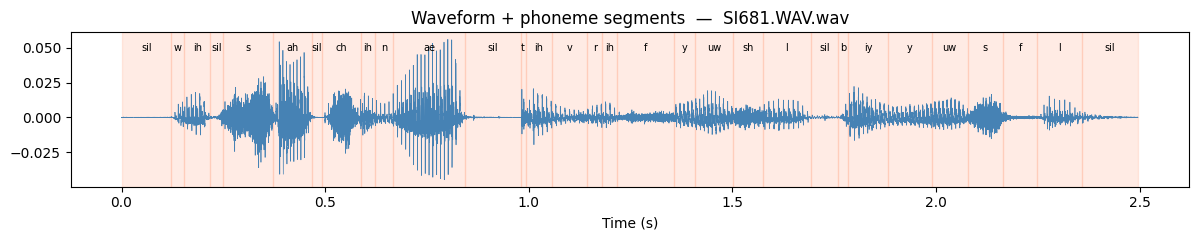

In [8]:
wav_path, phn_path = train_pairs[0]
audio    = load_audio(wav_path)
segments = read_phn_file(phn_path)

print(f'Audio length : {len(audio)} samples  ({len(audio)/SAMPLE_RATE:.2f} s)')
print(f'Phoneme segs : {len(segments)}')
print(f'Sequence     : {[IDX2PHONE[i] for _, _, i in segments]}')

fig, ax = plt.subplots(figsize=(12, 2.5))
t = np.arange(len(audio)) / SAMPLE_RATE
ax.plot(t, audio, linewidth=0.5, color='steelblue')
for start, end, idx in segments:
    ax.axvspan(start/SAMPLE_RATE, end/SAMPLE_RATE, alpha=0.15, color='coral')
    ax.text((start + end) / 2 / SAMPLE_RATE, audio.max() * 0.85,
            IDX2PHONE[idx], ha='center', fontsize=7)
ax.set_xlabel('Time (s)')
ax.set_title(f'Waveform + phoneme segments  —  {os.path.basename(wav_path)}')
fig.tight_layout()
plt.show()

ipd.display(ipd.Audio(audio, rate=SAMPLE_RATE))

We also check the phoneme frequency - how often each of the 39 phonemes appears in the first 500 utterances.

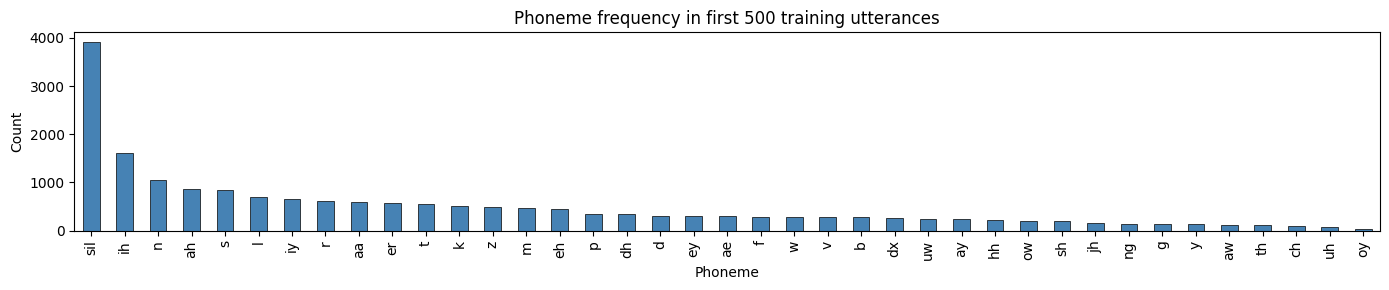

In [9]:
all_phones = []
for _, phn_path in train_pairs[:500]:
    all_phones.extend([IDX2PHONE[i] for _, _, i in read_phn_file(phn_path)])

phone_counts = pd.Series(all_phones).value_counts()
fig, ax = plt.subplots(figsize=(14, 3))
phone_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='k', linewidth=0.5)
ax.set_title('Phoneme frequency in first 500 training utterances')
ax.set_xlabel('Phoneme')
ax.set_ylabel('Count')
fig.tight_layout()
plt.show()

## 4. SSL Feature Extraction

Here we extract features from the pre-trained SSL models. Both *wav2vec2* and *HuBERT* have a CNN encoder at the front (7 conv layers, total stride = **320** samples), so they produce one feature vector every 20 ms.

We pass `output_hidden_states=True` to get all 13 internal representations:
- `hidden_states[0]`  - CNN output, before any transformer layer
- `hidden_states[k]`  - output after transformer block k  (k from 1 to 12)
- `last_hidden_state` - same as `hidden_states[12]`

We define the feature extraction function and a dataloader builder. The key idea: we run the heavy SSL model once per utterance upfront and save all the features. After that, training the small classifier works entirely on the saved numpy arrays - no SSL model needed.

In [10]:
def parameter_counter(model, model_name):
    n = sum(p.numel() for p in model.parameters())
    print(f'{model_name} parameters: {n:,}')

def extract_features(file_pairs, processor, ssl_model, device,
                     layer='last', desc='Extracting'):
    ssl_model.eval()
    feats_list, labels_list, refs_list = [], [], []

    with torch.no_grad():
        for wav_path, phn_path in tqdm(file_pairs, desc=desc, leave=False):
            audio  = load_audio(wav_path)
            inputs = processor(
                audio, sampling_rate=SAMPLE_RATE, return_tensors='pt'
            ).input_values.to(device)

            out = ssl_model(inputs, output_hidden_states=True)

            if layer == 'last':
                h = out.last_hidden_state
            else:
                h = out.hidden_states[layer]

            feats  = h.squeeze(0).cpu().float().numpy()
            T      = feats.shape[0]
            segs   = read_phn_file(phn_path)
            labels = segments_to_frame_labels(segs, T)
            ref    = get_reference_phones(phn_path)

            feats_list.append(feats)
            labels_list.append(labels)
            refs_list.append(ref)

    return feats_list, labels_list, refs_list

def build_loader(feats_list, labels_list, batch_size=2048, shuffle=True):
    X = torch.from_numpy(np.concatenate(feats_list,  axis=0))
    y = torch.from_numpy(np.concatenate(labels_list, axis=0))
    return DataLoader(TensorDataset(X, y), batch_size=batch_size,
                      shuffle=shuffle, num_workers=0)

## 5. Model and Training

Our classifier is a small neural network called `MLPProbe` (MLP = Multi-Layer Perceptron, basically a few stacked linear layers). It takes one SSL feature vector and predicts which of the 39 phonemes it belongs to.

We also write the training loop, a PER evaluation function (PER = Phoneme Error Rate - the percentage of phonemes the model gets wrong), and a `run_experiment` function that wraps everything together.

Here is our classifier. It has one hidden layer (768 -> 512), a LayerNorm to stabilize training, ReLU activation, a small Dropout for regularization, and a final output layer (512 -> 39 phoneme classes).

In [11]:
class MLPProbe(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=512, num_classes=NUM_PHONEMES, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )
    def forward(self, x): return self.net(x)

These three functions handle all the training logic:
- `train_epoch` runs one full pass through the training data and updates the model weights
- `compute_per` evaluates the model: it decodes frame predictions into a phoneme sequence (by collapsing consecutive identical frames) and computes the edit distance against the reference
- `run_experiment` puts it all together - loads the SSL model, extracts features, trains the MLP, and reports PER

In [12]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = total_correct = total = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item() * len(y)
        total_correct += (logits.argmax(-1) == y).sum().item()
        total         += len(y)
    return total_loss / total, total_correct / total


def compute_per(model, feats_list, refs_list, device):
    model.eval()
    total_dist = total_len = 0
    with torch.no_grad():
        for feats, ref in zip(feats_list, refs_list):
            logits = model(torch.from_numpy(feats).to(device))
            preds  = logits.argmax(-1).cpu().numpy()
            hyp, prev = [], -1
            for p in preds:
                if p != prev:
                    ph = IDX2PHONE[p]
                    if ph != 'sil':
                        hyp.append(ph)
                    prev = p
            if ref:
                total_dist += edit_distance(hyp, ref)
                total_len  += len(ref)
    return total_dist / max(total_len, 1)


def _train_mlp(input_dim, tr_f, tr_l, device, epochs=15, lr=1e-3,
               hidden_dim=512, verbose=True):
    loader    = build_loader(tr_f, tr_l, shuffle=True)
    model     = MLPProbe(input_dim, hidden_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(1, epochs + 1):
        loss, acc = train_epoch(model, loader, optimizer, criterion, device)
        scheduler.step()
        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(f'  epoch {epoch:2d}/{epochs}  loss {loss:.4f}  acc {acc:.4f}')
    return model


def run_experiment(name, model_id, ssl_cls, layer, train_pairs, test_pairs,
                   device, epochs=15, lr=1e-3, hidden_dim=512):
    ckpt = _ckpt_path(f'exp_{name}')
    if os.path.isfile(ckpt):
        data = torch.load(ckpt, map_location='cpu', weights_only=False)
        print(f'{name}  (checkpoint)  PER {data["per"]*100:.2f}%')
        return dict(name=name, per=data['per'])

    print(f'\n{name}')
    processor = AutoFeatureExtractor.from_pretrained(model_id)
    ssl       = ssl_cls.from_pretrained(model_id).to(device)
    ssl.requires_grad_(False)
    input_dim = ssl.config.hidden_size

    tr_f, tr_l, tr_r = extract_features(train_pairs, processor, ssl, device, layer, 'Train')
    te_f, te_l, te_r = extract_features(test_pairs,  processor, ssl, device, layer, 'Test')

    del ssl, processor
    torch.cuda.empty_cache(); gc.collect()

    model = _train_mlp(input_dim, tr_f, tr_l, device, epochs, lr, hidden_dim)
    per   = compute_per(model, te_f, te_r, device)
    print(f'  PER: {per*100:.2f}%')

    torch.save({'state_dict': model.state_dict(), 'per': per, 'input_dim': input_dim}, ckpt)
    return dict(name=name, per=per, model=model, te_f=te_f, te_r=te_r)


def run_layer_sweep(model_id, ssl_cls, layer_ids, train_pairs, test_pairs,
                    device, epochs=15):
    ckpt = _ckpt_path(f'sweep_{model_id.replace("/", "_")}')
    if os.path.isfile(ckpt):
        data = torch.load(ckpt, map_location='cpu', weights_only=False)
        print(f'{model_id} layer sweep  (checkpoint)')
        for lid, per in data['layer_pers'].items():
            lname = 'CNN' if lid == 0 else f'layer {lid}'
            print(f'  {lname}: PER {per*100:.2f}%')
        return data['layer_pers']

    print(f'\n{model_id}  —  layer sweep')
    processor = AutoFeatureExtractor.from_pretrained(model_id)
    ssl       = ssl_cls.from_pretrained(model_id).to(device)
    ssl.requires_grad_(False); ssl.eval()
    input_dim = ssl.config.hidden_size

    train_labels, train_refs, test_labels, test_refs = [], [], [], []
    with torch.no_grad():
        for wav_path, phn_path in tqdm(train_pairs, desc='Labels train', leave=False):
            audio = load_audio(wav_path)
            inp   = processor(audio, sampling_rate=SAMPLE_RATE,
                              return_tensors='pt').input_values.to(device)
            T     = ssl(inp, output_hidden_states=False).last_hidden_state.shape[1]
            train_labels.append(segments_to_frame_labels(read_phn_file(phn_path), T))
            train_refs.append(get_reference_phones(phn_path))
        for wav_path, phn_path in tqdm(test_pairs, desc='Labels test', leave=False):
            audio = load_audio(wav_path)
            inp   = processor(audio, sampling_rate=SAMPLE_RATE,
                              return_tensors='pt').input_values.to(device)
            T     = ssl(inp, output_hidden_states=False).last_hidden_state.shape[1]
            test_labels.append(segments_to_frame_labels(read_phn_file(phn_path), T))
            test_refs.append(get_reference_phones(phn_path))

    layer_pers = {}
    for layer_id in layer_ids:
        lname = 'CNN' if layer_id == 0 else f'layer {layer_id}'
        tr_feats, te_feats = [], []
        with torch.no_grad():
            for wav_path, _ in tqdm(train_pairs, desc=f'  train {lname}', leave=False):
                audio = load_audio(wav_path)
                inp   = processor(audio, sampling_rate=SAMPLE_RATE,
                                  return_tensors='pt').input_values.to(device)
                h     = ssl(inp, output_hidden_states=True).hidden_states[layer_id]
                tr_feats.append(h.squeeze(0).cpu().float().numpy())
            for wav_path, _ in tqdm(test_pairs, desc=f'  test  {lname}', leave=False):
                audio = load_audio(wav_path)
                inp   = processor(audio, sampling_rate=SAMPLE_RATE,
                                  return_tensors='pt').input_values.to(device)
                h     = ssl(inp, output_hidden_states=True).hidden_states[layer_id]
                te_feats.append(h.squeeze(0).cpu().float().numpy())

        model = _train_mlp(input_dim, tr_feats, train_labels, device, epochs, verbose=False)
        per   = compute_per(model, te_feats, test_refs, device)
        layer_pers[layer_id] = per
        print(f'  {lname}: PER {per*100:.2f}%')

        del tr_feats, te_feats, model
        gc.collect()

    del ssl, processor
    torch.cuda.empty_cache(); gc.collect()

    torch.save({'layer_pers': layer_pers}, ckpt)
    return layer_pers

## 6. Experiment 1 - wav2vec2-base (last hidden state)

`facebook/wav2vec2-base` was pre-trained on 960 hours of LibriSpeech with a contrastive objective: the model learns to pick the correct quantized speech unit at positions that were masked out. We freeze this model and use its last hidden state (the output of the final transformer layer) as features.

Time to run the first experiment. This will extract features from all training and test utterances, then train the MLP for 15 epochs and report the final PER.

In [13]:
res_w2v_last = run_experiment(
    name        = 'wav2vec2-base  |  last layer',
    model_id    = 'facebook/wav2vec2-base',
    ssl_cls     = Wav2Vec2Model,
    layer       = 'last',
    train_pairs = train_pairs,
    test_pairs  = test_pairs,
    device      = DEVICE,
    epochs      = 15,
)


wav2vec2-base  |  last layer


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  epoch  1/15  loss 1.2706  acc 0.6315
  epoch  5/15  loss 0.6847  acc 0.7866
  epoch 10/15  loss 0.5701  acc 0.8213
  epoch 15/15  loss 0.5131  acc 0.8394
  PER: 38.31%


### Visualise wav2vec2 features for a sample utterance

We briefly reload the model to plot what the feature vectors look like - both from the last transformer layer and from the middle (layer 6). This gives us a visual sense of how the representations differ between layers.

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

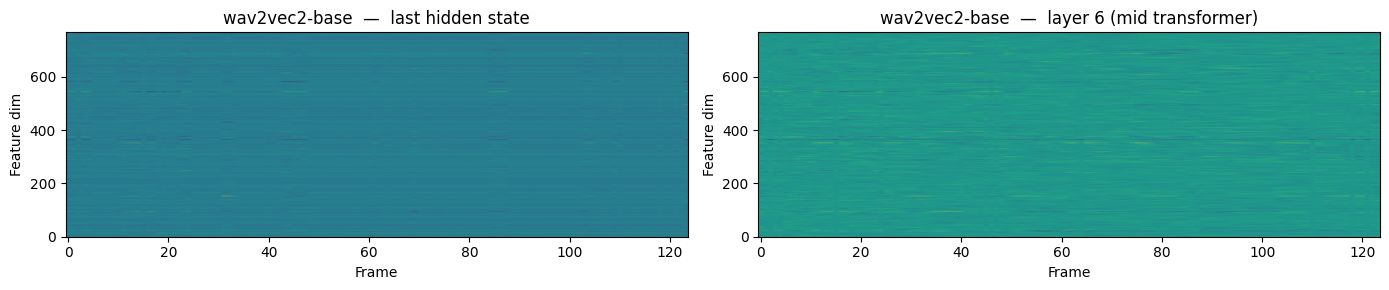

137

In [14]:
processor_viz = AutoFeatureExtractor.from_pretrained('facebook/wav2vec2-base')
ssl_viz       = Wav2Vec2Model.from_pretrained('facebook/wav2vec2-base').to(DEVICE)
ssl_viz.eval()

wav_path, phn_path = train_pairs[0]
audio = load_audio(wav_path)
inp   = processor_viz(audio, sampling_rate=SAMPLE_RATE, return_tensors='pt').input_values.to(DEVICE)

with torch.no_grad():
    out = ssl_viz(inp, output_hidden_states=True)

feat_last = out.last_hidden_state.squeeze(0).cpu().numpy()
feat_mid  = out.hidden_states[6].squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].imshow(feat_last.T, aspect='auto', origin='lower')
axes[0].set_title('wav2vec2-base  —  last hidden state')
axes[0].set_xlabel('Frame'); axes[0].set_ylabel('Feature dim')
axes[1].imshow(feat_mid.T, aspect='auto', origin='lower')
axes[1].set_title('wav2vec2-base  —  layer 6 (mid transformer)')
axes[1].set_xlabel('Frame'); axes[1].set_ylabel('Feature dim')
fig.tight_layout()
plt.show()

del ssl_viz, processor_viz
torch.cuda.empty_cache()
gc.collect()

## 7. Experiment 2 - HuBERT-base (last hidden state)

`facebook/hubert-base-ls960` was trained differently. Instead of a contrastive ranking task, it predicts **cluster labels** at masked positions - the targets come from k-means clustering on MFCC features. This pushes the model to directly learn discrete phoneme-like categories, so we expect HuBERT to produce better phoneme features than wav2vec2.

Same setup as before - we run the experiment and report PER.

In [15]:
res_hubert_last = run_experiment(
    name        = 'HuBERT-base-ls960  |  last layer',
    model_id    = 'facebook/hubert-base-ls960',
    ssl_cls     = HubertModel,
    layer       = 'last',
    train_pairs = train_pairs,
    test_pairs  = test_pairs,
    device      = DEVICE,
    epochs      = 15,
)


HuBERT-base-ls960  |  last layer


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  epoch  1/15  loss 0.5671  acc 0.8259
  epoch  5/15  loss 0.3215  acc 0.8850
  epoch 10/15  loss 0.2588  acc 0.9042
  epoch 15/15  loss 0.2272  acc 0.9161
  PER: 15.09%


## 8. Layer Analysis - wav2vec2-base

We check this ourselves by testing layers `{0, 3, 6, 9, 12}` of wav2vec2-base. All layers are extracted in one single forward pass, so we only run the model once.

We go through each layer one at a time: extract its features, train an MLP, record PER, then delete the features before moving to the next layer. This way only one layer's worth of data sits in RAM at any given moment.

In [16]:
LAYER_IDS  = [0, 3, 6, 9, 12]

layer_pers = run_layer_sweep(
    model_id    = 'facebook/wav2vec2-base',
    ssl_cls     = Wav2Vec2Model,
    layer_ids   = LAYER_IDS,
    train_pairs = train_pairs,
    test_pairs  = test_pairs,
    device      = DEVICE,
)

xs = list(layer_pers.keys())
ys = [layer_pers[l] * 100 for l in xs]
print(f'\nBest layer: {min(layer_pers, key=layer_pers.get)}  ({min(layer_pers.values())*100:.2f}%)')


facebook/wav2vec2-base  —  layer sweep


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  CNN: PER 46.40%


  layer 3: PER 36.69%


  layer 6: PER 21.67%


  layer 9: PER 22.37%


  layer 12: PER 37.56%

Best layer: 6  (21.67%)


Now we plot PER against layer index to see the pattern: which layer gives the lowest error?

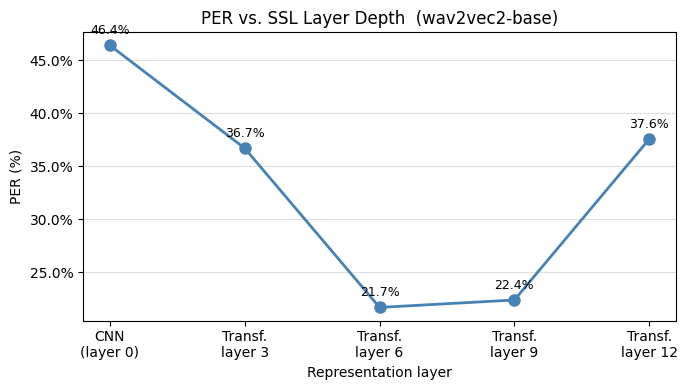

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
xs = list(layer_pers.keys())
ys = [layer_pers[l] * 100 for l in xs]
ax.plot(xs, ys, marker='o', linewidth=2, markersize=8, color='steelblue')
for x, y in zip(xs, ys):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9)
ax.set_xticks(xs)
ax.set_xticklabels(['CNN\n(layer 0)'] + [f'Transf.\nlayer {l}' for l in xs[1:]])
ax.set_xlabel('Representation layer')
ax.set_ylabel('PER (%)')
ax.set_title('PER vs. SSL Layer Depth  (wav2vec2-base)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.grid(axis='y', alpha=0.4)
fig.tight_layout()
plt.savefig('layer_per_comparison.png', dpi=120)
plt.show()

Now we do the same layer sweep for HuBERT. Since HuBERT already scored 15.15% on the last layer, its best layer should be noticeably lower.

In [18]:
hubert_layer_pers = run_layer_sweep(
    model_id    = 'facebook/hubert-base-ls960',
    ssl_cls     = HubertModel,
    layer_ids   = LAYER_IDS,
    train_pairs = train_pairs,
    test_pairs  = test_pairs,
    device      = DEVICE,
)

xh = list(hubert_layer_pers.keys())
yh = [hubert_layer_pers[l] * 100 for l in xh]
print(f'\nBest layer: {min(hubert_layer_pers, key=hubert_layer_pers.get)}  ({min(hubert_layer_pers.values())*100:.2f}%)')


facebook/hubert-base-ls960  —  layer sweep


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  CNN: PER 48.19%


  layer 3: PER 42.18%


  layer 6: PER 22.92%


  layer 9: PER 17.20%


  layer 12: PER 15.11%

Best layer: 12  (15.11%)


And here's the PER curve for HuBERT.

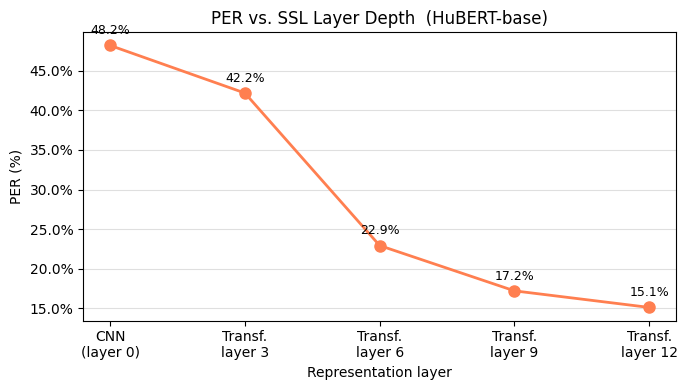

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
xh = list(hubert_layer_pers.keys())
yh = [hubert_layer_pers[l] * 100 for l in xh]
ax.plot(xh, yh, marker='o', linewidth=2, markersize=8, color='coral')
for x, y in zip(xh, yh):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9)
ax.set_xticks(xh)
ax.set_xticklabels(['CNN\n(layer 0)'] + [f'Transf.\nlayer {l}' for l in xh[1:]])
ax.set_xlabel('Representation layer')
ax.set_ylabel('PER (%)')
ax.set_title('PER vs. SSL Layer Depth  (HuBERT-base)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.grid(axis='y', alpha=0.4)
fig.tight_layout()
plt.savefig('hubert_layer_per_comparison.png', dpi=120)
plt.show()


## 9. Results

A simple table with the final PER for each configuration.

In [20]:
results_table = [
    ('wav2vec2-base,  last layer',  res_w2v_last['per']),
    ('HuBERT-base,    last layer',  res_hubert_last['per']),
    ('wav2vec2-base,  best layer',  min(layer_pers.values())),
    ('HuBERT-base,    best layer',  min(hubert_layer_pers.values())),
]

print(f"{'Model / Configuration':<44} {'PER':>8}")
print('-' * 54)
for name, per in results_table:
    print(f'{name:<44} {per*100:7.2f}%')


Model / Configuration                             PER
------------------------------------------------------
wav2vec2-base,  last layer                     38.31%
HuBERT-base,    last layer                     15.09%
wav2vec2-base,  best layer                     21.67%
HuBERT-base,    best layer                     15.11%


And the same results visualized: a bar chart for the three experiments, plus the layer-vs-PER curve from Experiment 3.

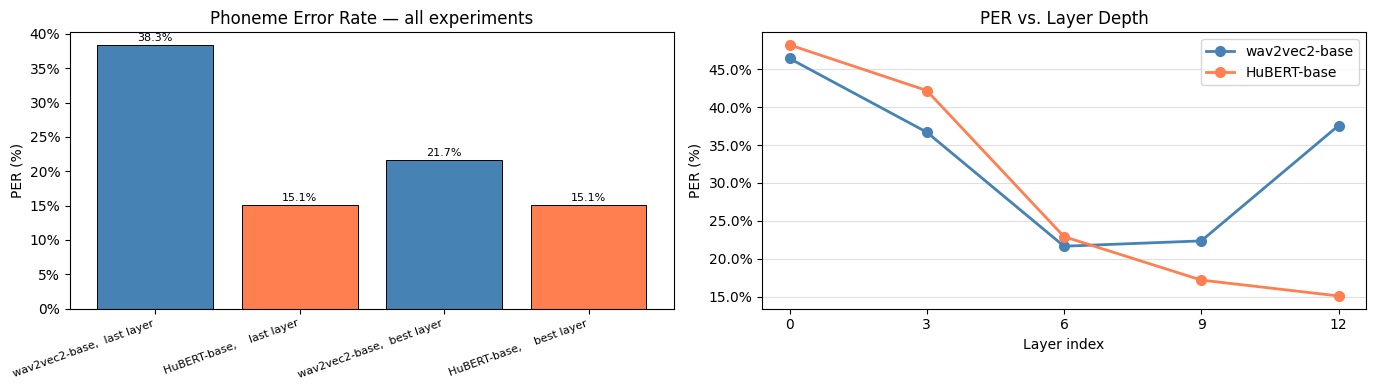

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

names  = [r[0] for r in results_table]
pers   = [r[1] * 100 for r in results_table]
colors = ['steelblue', 'coral', 'steelblue', 'coral']
bars   = axes[0].bar(range(len(names)), pers, color=colors, edgecolor='k', linewidth=0.7)
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=20, ha='right', fontsize=8)
axes[0].set_ylabel('PER (%)')
axes[0].set_title('Phoneme Error Rate — all experiments')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
for bar, v in zip(bars, pers):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

axes[1].plot(xs, ys, marker='o', color='steelblue', linewidth=2, markersize=7, label='wav2vec2-base')
axes[1].plot(xh, yh, marker='o', color='coral',     linewidth=2, markersize=7, label='HuBERT-base')
axes[1].set_xticks(xs)
axes[1].set_xlabel('Layer index')
axes[1].set_ylabel('PER (%)')
axes[1].set_title('PER vs. Layer Depth')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.4)

fig.tight_layout()
plt.savefig('results_summary.png', dpi=120)
plt.show()


## Conclusions

**SSL model choice matters more than anything else.** HuBERT-base (15% PER) outperforms wav2vec2-base (37% PER) by a large margin when using the last hidden layer as features. The gap comes from training objectives: wav2vec2 uses contrastive learning over quantized speech units, while HuBERT predicts discrete cluster labels — a task much closer to phoneme classification.

**Layer depth matters for wav2vec2, less so for HuBERT.** For wav2vec2-base, the best results come from middle transformer layers (around layer 6–9), not the final layer. The last layer encodes more abstract, less acoustically grounded information. HuBERT shows a different pattern — PER decreases monotonically across layers and layer 12 is already the best, suggesting the whole model is more consistently organized around phoneme-like categories.

**Decoding is simple but effective.** Collapsing consecutive identical frame predictions and removing silence frames produces a clean phoneme sequence that scores well against the reference using edit distance.